# Análisis de Supervivencia

En el análisis de supervivencia estamos interesados en un tipo de variable respuesta: el tiempo hasta la ocurrencia de un evento.

Por ejemplo, supongamos que estamos realizando un estudio sobre pacientes a los que se les ha administrado un tratamiento contra el cáncer. Nos gustaría ajustar un modelo para predecir el tiempo de supervivencia de los pacientes, usando para esto covariables como sus mediciones de salud o tipo de tratamiento. En este tipo de problemas no podemos usar técnicas de regresión usuales pues en nuestros datos existen pacientes para los que no conocemos su tiempo de supervivencia, pues pudieron morir después de la finalización del estudio o también pudieron haber desertado del estudio. En este caso decimos que el tiempo de supervivencia del paciente está *censurado*. Aún así, queremos hacer uso de esta información en el análisis.

## Tiempo de supervivencia y tiempo de censura

Para cada individuo suponemos que existe un tiempo de supervivencia $T$, así como un tiempo de censura $C$. El tiempo de supervivencia representa el tiempo en el que el evento de interés ocurre, por ejemplo, el tiempo en el que el paciente de cáncer muere. El tiempo de censura representa el tiempo en el que  la censura ocurre: el paciente abandona el estudio, o bien, el estudio termina.

Observamos la variable $Y= min(T,C).$ Es decir, si el evento ocurre antes de la censura $(T<C)$, entonces observamos $T$. Si por el contrario la censura ocurre antes que el evento de interés, ($T>C$), entonces observamos $C$.

Además observamos un indicador de estatus:

$$
\delta =
\begin{cases}
1 & \text{si } T \leq C \\
0  & \text{si } T > C
\end{cases}
$$

## La curva de supervivencia de Kaplan-Meier

La *curva de supervivencia* o *función de supervivencia*, se define como

$$S(t)=P(T>t).$$

En nuestro ejemplo de pacientes de cáncer, $S(t)$ representa la probabilidad de que un paciente muera después de un tiempo $t$.

**¿Cómo estimar la curva de supervivencia?**

Supongamos que deseamos estimar $S(20)=Pr(T>20)$, la probabilidad de que un paciente viva al menos 20 meses durante el estudio. Uno podría querer estimar esta probabilidad como la proporción de pacientes que sabemos vivieron al menos 20 meses, es decir, aquellos pacientes con $Y>20$. Pero esto no es correcto ya que $T$ y $Y$ son variables diferentes. Para aquellos pacientes con $Y\leq 20$ podría ocurrir $C\leq 20$ pero $T>20$.

Alternativamente, podríamos pensar que podemos estimar $S(20)$ como la proporción de los pacientes con $Y>20$ entre los pacientes que no han sido censurados al tiempo $t=20$. Pero aún así estamos quitando información, alguien censurado al tiempo $t=19.9$ podría sobrevivir después de $t=20$.

Estimar $S(t)$ en general es difícil debido a la presencia de censura en los datos. Presentamos un enfoque para superar estos inconvenientes. Sean $d_1 < d_2 < \cdots < d_K$ los $K$ tiempos de muerte en los pacientes no censurados, y sea $q_k$ el número de pacientes que mueren en el tiempo $t=d_k$. Para $k=1, \dots, K$ sea $r_k$ el número de pacientes vivos y dentro del estudio justo antes de $d_k$, estos son los *pacientes en riesgo*. El conjunto de los pacientes que están en riesgo a un tiempo determinado es llamado el *conjunto de riesgo*.

Por la ley de probabilidad total tenemos que

$$Pr(T>d_k)=Pr(T>d_k|T>d_{k-1})Pr(T>d_{k-1})+Pr(T>d_k|T\leq d_{k-1})Pr(T\leq d_{k-1}),$$

pero ya que $d_k> d_{k-1}$, $Pr(T>d_k|T\leq d_{k-1})=0$. Por tanto,

$$S(d_k)=Pr(T>d_k)=Pr(T>d_k|T>d_{k-1})Pr(T>d_{k-1})=Pr(T>d_k|T>d_{k-1})S(d_{k-1)}.$$

Esto implica que

$$S(d_k)=Pr(T>d_k|T>d_{k-1})Pr(T>d_{k-1}|T>d_{k-2})\cdots Pr(T>d_2|T>d_1)Pr(T>d_1).$$

Ahora solo debemos estimar cada término del lado derecho de nuestra última ecuación. Es natural estimar estos términos mediante:

$$\hat{Pr}(T>d_j|T>d_{j-1})=\frac{r_j-q_j}{r_j},$$

esto nos lleva directamente a escribir el estimado de Kaplan-Meier para la curva de supervivencia:

$$\hat{S}(d_k)=\prod_{j=1}^k\frac{r_j-q_j}{r_j}$$

## Modelos de Regresión con una respuesta de supervivencia

Ahora consideramos el problema de ajustar un modelo de regresión a los datos de supervivencia. Nuestras observaciones son de la forma $(Y, \delta)$, donde $Y$ es el tiempo (posiblemente censurado) de supervivencia, y $\delta$ la indicadora de $(T\leq C)$. Adicionalmente, $\mathbf{X} \in \mathbb{R}^p$ es nuestro vector de covariables. Deseamos predecir el verdadero tiempo de supervivencia $T$.

Así como sucedió cuando estimamos la curva de supervivencia, los tiempos de censura crean problemas.

## La función de riesgo

La función de riesgo es definida como:


$$h(t)=\lim_{\Delta t\to 0}\frac{Pr(t<T\leq t+\Delta t|T>t)}{\Delta t},$$

la cual también se puede escribir como

$$h(t)=\frac{f(t)}{S(t)},$$

donde $f(t)=\lim_{\Delta t\to 0}\frac{Pr(t<T\leq t+\Delta t)}{\Delta t}$, la función de densidad de probabilidad asociada a $T$.

Si tenemos la función de riesgo, la función de supervivencia se puede obtener mediante la función de riesgo acumulada, $H(t)=\int_0^th(s)ds$, a través de:

$$S(T)=\exp[-H(t)]$$

La verosimilitud asociada con la i-ésima observación es:

$$
L_i =
\begin{cases}
f(y_i) & \text{si la i-ésima observación no es censurada} \\
S(y_i)  & \text{si la i-ésima observación es censurada }
\end{cases}
$$

$L_i=f(y_i)^{\delta_i}S(y_i)^{1-\delta_i}$. Suponiendo que las $n$ observaciones son independientes, la verosimilitud para los datos toma la forma

$$L=\prod_{i=1}^n f(y_i)^{\delta_i}S(y_i)^{1-\delta_i}=\prod_{i=1}^nh(y_i)^{\delta_i}S(y_i).$$

Deseamos modelar el tiempo de supervivencia como función de las covariables. Para hacer esto vamos a suponer una forma funcional para la función de riesgo:

$$h(t|\mathbf{x_i})=\exp(\beta_0+\sum_{j=1}^p\beta_jx_{ij}).$$

Si además consideramos el **supuesto de riesgo proporcional:**

$$h(t|\mathbf{x_i})=h_0(t)\exp(\sum_{j=1}^p\beta_jx_{ij}),$$

donde $h_0(t)\geq 0$ es conocida como la *riesgo base*. Es la función de riesgo para un individuo con covariables iguales a cero. Su forma se supone desconocida.

## Modelo de Cox con el supuesto de riesgo proporcional

Debido a que no conocemos la forma de $h_0(t)$, no podemos tomar la función de riesgo, y sustituirla en la función de verosimilitud para estimar $\boldsymbol{\beta}=(\beta_1, ..., \beta_p)^T$ por máxima verosimilitud.
En este modelo de Cox es posible estimar $\boldsymbol{\beta}$ sin necesidad de conocer $h_0(t)$. Suponga que la i-ésima observación no es censurada, i.e. $y_i$ es el tiempo de ocurrencia. Entonces, la función de riesgo para la i-ésima observación es $h(y_i|\mathbf{x_i})=h_0(y_i)\exp(\sum_{j=0}^px_{ij}\beta_j)$, mientra que para el conjunto de riesgo en el tiempo $y_i$ la función de riesgo total es

$$\sum_{i':y_{i'}\geq y_i}h_0(y_i)\exp(\sum_{j=1}^px_{i'j}\beta_j).$$

Por lo tanto, la probabilidad de que la i-ésima observación sea la que ocurre al tiempo $y_i$ es:

$$\frac{h_0(y_i)\exp(\sum_{j=0}^px_{ij}\beta_j)}{\sum_{i':y_{i'}\geq y_i}h_0(y_i)\exp(\sum_{j=1}^px_{i'j}\beta_j)}=\frac{\exp(\sum_{j=0}^px_{ij}\beta_j)}{\sum_{i':y_{i'}\geq y_i}\exp(\sum_{j=1}^px_{i'j}\beta_j)}.$$

La verosimilitud parcial es simplemente el producto de estas probabilidades sobre todas las observaciones no censuradas,

$$PL(\boldsymbol{\beta})=\prod_{i:\delta_i=1}\frac{\exp(\sum_{j=0}^px_{ij}\beta_j)}{\sum_{i':y_{i'}\geq y_i}\exp(\sum_{j=1}^px_{i'j}\beta_j)}.$$

La verosimilitud parcial es válida a pesar del verdadero valor de $h_0(t),$ haciendo el modelo flexible y robusto. Se llama verosimilitud parcial debido a que no es exactamente una verosimilitud, es decir, no corresponde exactamente  a la probabilidad de observar los datos bajo el supuesto de riesgo proporcional.

Para estimar $\beta$, maximizamos la verosimilitud parcial con respecto a $\beta$. No existe solución analítica por lo que requerimos algoritmos iterativos para el problema de optimización.

##Ejemplo: Datos de cancer cerebral

Usaremos el dataset BrainCancer que contiene los tiempos de supervivencia de pacientes con tumor cerebral primario siguiendo tratamiento con métodos de radiación estereotácticos. Las covariables son

gtv: gross tumor volume, en $cm^3$

sex: hombre o mujer

diagnosis: meningioma, LG glioma, HG glioma, o otro

loc: locación del tumor, infratentorial o supratentorial

ki: Karfnosky index

stereo: método  estereotáctico, SRS o SRT.

Solamente 53 de los 88 pacientes estaban vivos al final del estudio.







In [7]:
%%capture
!pip install ISLP

In [8]:
from matplotlib.pyplot import subplots
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS
from ISLP import load_data

In [9]:
from lifelines import \
     (KaplanMeierFitter,
      CoxPHFitter)
from lifelines.statistics import \
     (logrank_test,
      multivariate_logrank_test)
from ISLP.survival import sim_time

In [10]:
BrainCancer=load_data('BrainCancer')
BrainCancer.head()

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


A continuación  vamos a graficar la curva de supervivencia de Kaplan-Meier

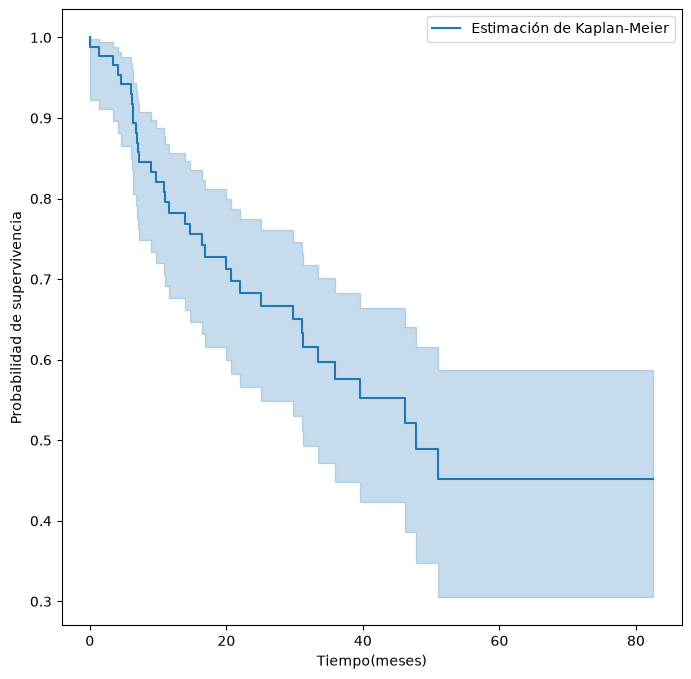

In [11]:
fig, ax=subplots(figsize=(8,8))
km=KaplanMeierFitter()
km_brain=km.fit(BrainCancer['time'],BrainCancer['status'])
km_brain.plot(label='Estimación de Kaplan-Meier', ax=ax)
ax.set_xlabel('Tiempo(meses)')
ax.set_ylabel('Probabilidad de supervivencia')
ax.legend()

Ahora usaremos el estimador CoxPHFitter() de lifeline para ajusta el modelo de Cox. Para iniciar, consideramos un modelo que solamente usa sex como covariable.

In [12]:
coxph=CoxPHFitter
sex_df=BrainCancer[['time','status','sex']]
model_df=MS(['time', 'status', 'sex'], intercept=False).fit_transform(sex_df)
cox_fit=coxph().fit(model_df, 'time', 'status')
cox_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.407668,0.342004,0.233262


Ahora ajustamos un modelo que usa covariables adicionales

In [13]:
# Hay un valor faltante en diagnosis
cleaned = BrainCancer.dropna()
all_MS = MS(cleaned.columns, intercept = False)
all_df = all_MS.fit_transform(cleaned)
fit_all = coxph().fit(all_df, 'time', 'status')
fit_all.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.183748,0.360358,0.610119
diagnosis[LG glioma],-1.239530,0.579555,0.032455
diagnosis[Meningioma],-2.154566,0.450524,0.000002
diagnosis[Other],-1.268870,0.617672,0.039949
loc[Supratentorial],0.441195,0.703669,0.530665
ki,-0.054955,0.018314,0.002693
gtv,0.034293,0.022333,0.124661
stereo[SRT],0.177778,0.601578,0.767597


Finalmente vamos a plotear curvas de supervivencia para cada categoría de diagnosis.

In [14]:
levels = cleaned['diagnosis'].unique()
def representative(series):
    if hasattr(series.dtype, 'categories'):
      return pd.Series.mode(series)
    else:
      return series.mean()
modal_data = cleaned.apply(representative, axis=0)

In [15]:
modal_df = pd.DataFrame(
    [modal_data.iloc[0] for i in range(len(levels))])
modal_df['diagnosis'] = levels
modal_df

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,HG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,LG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,Other,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621


In [16]:
modal_X = all_MS.transform(modal_df)
modal_X.index = levels
modal_X

,sex[Male],diagnosis[LG glioma],diagnosis[Meningioma],diagnosis[Other],loc[Supratentorial],ki,gtv,stereo[SRT],status,time
Meningioma,0.0,0.0,1.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
HG glioma,0.0,0.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
LG glioma,0.0,1.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
Other,0.0,0.0,0.0,1.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621


In [17]:
predicted_survival=fit_all.predict_survival_function(modal_X)
predicted_survival

,Meningioma,HG glioma,LG glioma,Other
0.07,0.997947,0.982430,0.994881,0.995029
1.18,0.997947,0.982430,0.994881,0.995029
1.41,0.995679,0.963342,0.989245,0.989555
1.54,0.995679,0.963342,0.989245,0.989555
2.03,0.995679,0.963342,0.989245,0.989555
...,...,...,...,...
65.02,0.688772,0.040136,0.394181,0.404936
67.38,0.688772,0.040136,0.394181,0.404936
73.74,0.688772,0.040136,0.394181,0.404936
78.75,0.688772,0.040136,0.394181,0.404936


/tmp/ipykernel_277156/1523235932.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  predicted_survival.plot(ax=ax);


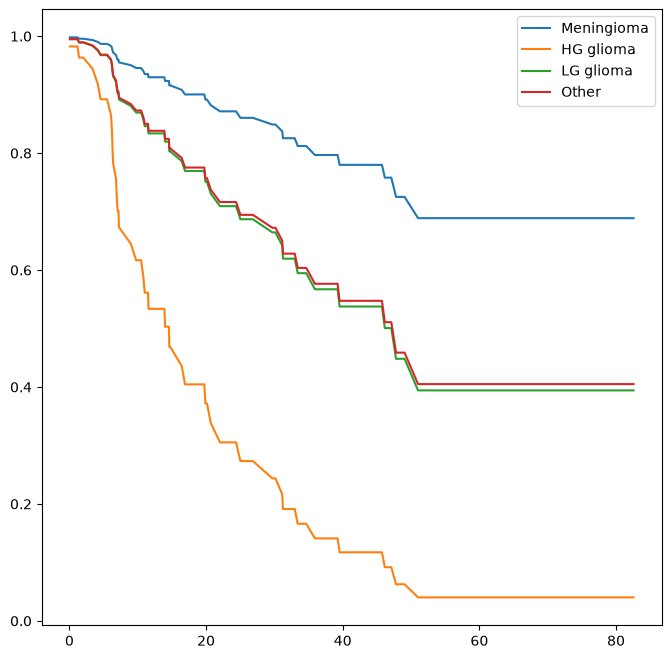

In [18]:
fig, ax = subplots(figsize=(8,8))
predicted_survival.plot(ax=ax);

# Predicción del tiempo de ocurrencia con redes neuronales y regresión de Cox

## Redes neuronales

## Antecedentes
La extensión de la regresión de Cox con redes neuronales fue propuesta por Faraggi y Simon (1995), quienes remplazaron el predictor lineal de la regresión de Cox, por una red neuronal MLP de una capa oculta. Sin embargo, Xiang et al. (2000) y Sargent (2001) encontraron que este modelo en general no logra superar al modelo clásico de Cox. Katzman et al. (2018) volvió a trabajar este modelo en el marco del deep learning (modelo DeepSurv). Lee et al. (2018) propusieron un método (modelo DeepHit) que estima la función de masa de probabilidad con una red neuronal y combina la log-verosimilitud con una pérdida de ranking. La mayoría de los artículos mencionados comparan sus métodos con los bosques de supervivencia aleatorios (RSF) de Ishwaran et al. (2008). RSF calcula un bosque aleatorio utilizando la prueba de rango logarítmico como criterio de división. Calcula los riesgos acumulativos de los nodos de hoja y los promedia sobre el conjunto. Por lo tanto, RSF es un método de tiempo continuo muy flexible que no está limitado por el supuesto de proporcionalidad.

## Retomando la regresión de Cox

Recordamos que bajo el supuesto proporcional de Hazard, la función de Hazard se puede escribir como

$$h(t|\mathbf{x})=h_0(t)\exp[g(\mathbf{x}],$$
con $g(\mathbf{x})=\boldsymbol{\beta}^T\mathbf{x}$, donde $\mathbf{x}\in \mathbb{R}^p$ es el vector de covariables, y $\boldsymbol{\beta}\in\mathbb{R}^p $ es el vector de parámetros. $h_0(t)$ la función de Hazard base, cuya forma es desconocida. A $\exp[g(\mathbf{x}]$ la llamamos *función de riesgo relativa*.

Con esta notación, la verosimilitud parcial se escribe como:

$$PL(\boldsymbol{\beta})=\prod_{i:\delta_i=1}\frac{\exp(g(\mathbf{x_i}))}{\sum_{i'\in R_i}\exp(g(\mathbf{x}_{i'}))}\tag{1},$$

donde $R_i$ denota al conjunto de individuos en riesgo al tiempo $t_i$.

Entonces la log-verosimilitud parcial negativa puede usarse como función de pérdida:

$$loss=\sum_{i:\delta_i=1}log\left(\sum_{i'\in R_i]}\exp(g(\mathbf{x}_{i'})-g(\mathbf{x}_i))\right).\tag{2}$$

Sea $\hat{\boldsymbol{\beta}}$ el valor de $\boldsymbol{\beta}$ que maximiza (1), o equivalentemente, que minimiza (2). Entonces la función base de Hazard acumulada puede ser estimada mediante el *estimador de Breslow*

$$\hat{H}_0(t)=\sum_{Y_i\leq t}\Delta \hat{H}_0(Y_i)\tag{3}$$

$$\Delta \hat{H}_0(Y_i)=\frac{\delta_i}{\sum_{i'\in R_i}\exp[\hat{g}(\mathbf{x}_{i'})]},$$

donde $\hat{g}(\mathbf{x})=\hat{\boldsymbol{\beta}}^T\mathbf{x}$.

## Cox con SGD

En general, la verosimilitud parcial (1) es maximizada utilizando el método de Newton-Raphson, pero para conjuntos de datos muy grandes se propone usar el SGD. Como la suma del denominador en (1) es sobre el conjunto de individuos en riesgo al tiempo $t_i$, al momento de escoger nuestros minibatches en el algoritmo SGD, la suma del denominador se reduce a los individuos de $R_i$ que están presentes en el minibatch actual. Esto funciona bien para modelos que siguen el supuesto de proporcionalidad de Cox. Para modelos que no siguen este supuesto (modelos no proporcionales) se propone la siguiente heurística para aproximar la pérdida:

Podemos aproximar el conjunto de riesgo $R_i$ con un conjunto suficientemente grande $\tilde{R}_i$ y ponderamos la pérdida con pesos $w_i$, de modo que nuestros $w_i$ hacen que la suma sobre $\tilde{R}_i$ aproxime a la suma sobre $R_i$:

$$L=\prod_{i:\delta_i=1}\frac{\exp(g(\mathbf{x_i}))}{w_i\sum_{i'\in \tilde{R}_i}\exp(g(\mathbf{x}_{i'}))}\tag{4}.$$

Fijamos un tamaño para los conjuntos $\tilde{R}_i$, podemos optimizar $L$ usando SGD. Además, escogemos $\tilde{R}_i$ de modo que contenga al individuo $i$ para asegurarnos que cada uno de los factores en (4) sea menos o igual que 1.

Como los pesos $w_i$ no contribuyen en el cálculo del gradiente de la log-verosimilitud, podemos quitarlos de nuestra expresión para la función de pérdida, finalmente, vamos a promediar la pérdida para hacerla independiente del tamaño del conjunto de datos. Obtenemos:

$$loss=\frac{1}{n}\sum_{i:\delta_i=1}log\left(\sum_{i'\in \tilde{R}_i}\exp[g(\mathbf{x}_j)-g(\mathbf{x}_i)]\right),\tag{5}$$

donde $n$ denota al tamaño del conjunto de datos. En los experimentos numéricos se encuentra que usualmente es suficiente muestrear un elemento del conjunto de riesgo, lo que nos da una función de pérdida:

$$loss=\frac{1}{n}\sum_{i:\delta_i=1}log(1+\exp[g(\mathbf{x}_j)-g(\mathbf{x}_i)])\tag{6},\text{ } j\in R_i\backslash \{i\}.$$

## Cox no lineal

Habiendo establecido la función de pérdida en (5), que puede ser calculada usando SGD, proponemos reemplazar el predictor lineal $g(\mathbf{x})=\boldsymbol{\beta}^T\mathbf{x}$, por una $g(\mathbf{x})$ parametrizada por una red neuronal. La generalización de $g(\mathbf{x})$ deja intacta la teoría anterior sobre la verosimilitud y la función de pérdida. Nos referiremos al modelo parametrizado por una red neuronal como el modelo Cox-MLP, y para diferenciar entre minimizar la log-verosimilitud parcial negativa, entre el método de DeepSurv y nuestra aproximación de caso-controlado (5), denotaremos los métodos por Cox-MLP (DeepSurv) y Cox-MLP (CC), respectivamente.

En este modelo parametrizado por una red neuronal, la pérdida no necesariamente tiene un único minimizador para $g(\mathbf{x})$, por lo que vamos a agregar una penalización

$$penalty=\lambda \sum_{i:\delta_i =1}\sum_{j\in \tilde{R}_i}|g(\mathbf{x}_j)|.$$

## Cox-time no proporcional

Continuando con la forma semi-paramétrica del modelo de Cox, ahora hacemos que la función de riesgo relativo dependa del tiempo:

$$h(t|\mathbf{x})=h_0(t)\exp[g(t,\mathbf{x}]\tag{7}.$$

Este modelo ya no es un modelo que siga el supuesto proporcional de Hazard. Sin embargo, es un modelo de riesgo relativo qeu tiene la misma verosimilitud parcial que antes, con una nueva covariable. Tenemos la siguiente función de pérdida para el modelo:

$$loss=\sum_{i:\delta_i=1}log\left( \sum_{i'\in \tilde{R}_i}\exp[g(Y_i,\mathbf{x}_{i'})-g(Y_i,\mathbf{x}_i)]\right)\tag{8},$$

e incluimos la penalización que discutimos previamente, con $g(Y_i,\mathbf{x}_j)$ reemplazando a $g(\mathbf{x}_j)$. Nos referiremos a este modelo como el modelo Cox-time.

## Predicciones

Podemos obtener predicciones estimando la función de
supervivencia mediante $ \hat{S}(t | \mathbf{x}) = \exp\left[-\hat{H}(t | \mathbf{x})\right] $. En los modelos que siguen el supuesto de proporcionalidad la función de riesgo relativo no depende del tiempo,
lo que nos permite integrar solo sobre el función de Hazard base y calcular la función de riesgo relativo por separado:

$$
H(t | \mathbf{x}) = \int_0^t h_0(s) \exp[g(\mathbf{x})] \, ds = H_0(t) \exp[g(\mathbf{x})].
$$

Estimamos $H_0(t)$ mediante el estimador de Breslow (3), solo necesitamos calcular $\exp[g(\mathbf{x})]$ para obtener predicciones.

En el caso de modelos que no siguen el supuesto proporcional, como el modelo Cox-time, las predicciones son mucho más costosas
computacionalmente. Dado que la función de riesgo relativo depende del tiempo, ahora necesitamos
integrar ambas funciones, la de riego relativo y la base de Hazard:


$$
H(t | \mathbf{x}) = \int_0^t h_0(s) \exp[g(s, \mathbf{x})] \, ds.
$$

En la práctica, estimamos la función de Hazard acumulada mediante

$$
\hat{H}(t | \mathbf{x}) = \sum_{Y_i \leq t} \Delta \hat{H}_0(T_i) \exp[\hat{g}(T_i, \mathbf{x})],
$$

donde $ \Delta \hat{H}_0(T_i) $ es un incremento de la estimación de Breslow y
$\hat{g}(Y_i, \mathbf{x}) $ es la estimación de $ g(Y_i, \mathbf{x}) $ obtenida de la red neuronal.
Esto es claramente bastante costoso computacionalmente, ya que necesitamos calcular
$ \hat{g}(T_i, x) $ para todos los distintos tiempos con $ Y_i \leq t $.
Además, para datos de tiempo continuo, el cálculo del riesgo base acumulado a través de
la estimación de Breslow,

$$
\Delta \hat{H}_0(Y_i) = \frac{\delta_i}{\sum_{j \in R_i} \exp[\hat{g}(T_i, \mathbf{x}_j)]},
$$

escala cuadráticamente.

Para aliviar el costo computacional, se puede calcular la Hazard acumulada sobre un
número reducido de puntos de tiempo distintos. Así, Cox-Time se entrena con datos de
tiempo continuo pero produce predicciones en tiempo discreto, con el beneficio de que
la discretización ocurre después de ajustar la red.

## Criterios de evaluación
1. Concordance index
2. Brier score
3. Binomial log-likelihood



#Referencias

 James, G., Witten, D., Hastie, T., Tibshirani, R. y Taylor, J. (2023). *An Introduction to
Statistical Learning. With applications in Python*. Springer

Kvamme, H., Borgan O., Scheel, I. (2019). *Time-to-Event Prediction with Neural Networks and Cox Regression*. Journal of Machine Learning Research 20 (2019) 1-30
